Pandas Uso 

El objetivo es usar framework de Pandas para procesar los datos obtenidos del API pyRofex . 

Prerequisitos :  Tener un usuario para ingresar a la aplicacion pyRofex . 
El usuario se obtiene de https://remarkets.primary.ventures/

API pyRofex tiene los datos del posiciones procesadas en mercado de futuros Rofex . 

La idea es lograr un correlacion del precio de la Soja que cotiza en Rosario . 

Soja que cotiza en Rosario tiene un precio en Dolares para cada mes . 
La funcion pyRofex.trade_history trae un diccionario con fecha , cantidad contratos hechos y precio del contrato .  


In [41]:
## Este script consulta el historial de precios de contratos de soja en Rofex de un año determinado de los meses de marzo a febrero del año siguiente.          
## Concatena los framework de cada mes en un solo DataFrame.
## El resultado es un DataFrame con las columnas: symbol, size, price, datetime y dia.  
## El resultado se guarda en un archivo Excel con el nombre del cereal y el año.
## Importe paquetes que voy necesitar  

import pandas as pd
import datetime
import pyRofex
import matplotlib.pyplot as plt


## Defino funcion que dado un instrumento y un rango de fechas, me devuelve el historial de precios
## de ese instrumento en un DataFrame con las columnas: symbol, size, price, datetime
def marketdata(instrument,end,start):
    ht = pyRofex.get_trade_history(ticker=instrument, start_date=start, end_date=end)
    tr=ht["trades"]
    ptr=pd.DataFrame(tr,columns=["symbol","size","price","datetime"]) ## Creo DataFrame con las columnas que necesito
    ptr["dia"]= pd.to_datetime( ptr["datetime"].str[:10], format='%Y-%m-%d') ## Creo columan dia
    ptr=ptr.drop(['datetime'], axis=1)  ##Saco columna datetiem
    ptr=ptr.set_index("dia") ## Seteo columna dia como indice
    ptr=ptr.iloc[1:] ## Borro el 1er Registro
    print(ptr)
    return ptr
    
ano = 25
cereal = "SOJ.ROS"
end = datetime.date.today() ## Fecha de hoy
start = datetime.date(year=2000+ano, month=1, day=1) ## Fecha de inicio del historial de precios
result=pd.DataFrame()## Data Frame Vacio
posiabi=[]


pyRofex.initialize(user="nperezchena21328",
                   password="ibghwY5$",
                   account="REM21328",
                   environment=pyRofex.Environment.REMARKET)
print("Consulta Rofex")
print(ano,cereal,end,start)
inst=["MAR","ABR","MAY","JUN","JUL","AGO","SEP","OCT","NOV","DIC","ENE","FEB"]

for inst1 in inst:
        if inst1=="Ene" or inst1=="Feb":
            posi=cereal+"/"+1+str(ano+1)
        else:
            posi=cereal+"/"+inst1+str(ano)
        print(posi)
        result1 = marketdata(posi,end,start)
        if len(result1)>1:
            result = pd.concat([result, result1], axis=0, sort=False)  # Concatenate along rows
            posiabi.append(posi)
            print(posi, len(result1), len(result), posiabi)



result.to_excel(cereal+str(ano)+'contratos.xlsx')
 



Consulta Rofex
25 SOJ.ROS 2025-06-03 2025-01-01
SOJ.ROS/MAR25
                   symbol  size  price
dia                                   
2025-02-05  SOJ.ROS/MAR25   2.0  295.0
2025-02-20  SOJ.ROS/MAR25   2.0  300.0
2025-02-26  SOJ.ROS/MAR25   1.0  295.0
2025-03-07  SOJ.ROS/MAR25   5.0  298.0
2025-03-11  SOJ.ROS/MAR25   3.0  297.0
2025-03-21  SOJ.ROS/MAR25   3.0  300.0
2025-03-21  SOJ.ROS/MAR25   7.0  300.0
2025-03-21  SOJ.ROS/MAR25   1.0  300.0
2025-03-21  SOJ.ROS/MAR25   1.0  300.0
2025-03-21  SOJ.ROS/MAR25   1.0  300.0
2025-03-21  SOJ.ROS/MAR25   1.0  300.0
2025-03-21  SOJ.ROS/MAR25   1.0  300.0
2025-03-21  SOJ.ROS/MAR25   1.0  300.0
2025-03-21  SOJ.ROS/MAR25   1.0  300.0
2025-03-21  SOJ.ROS/MAR25   1.0  300.0
2025-03-21  SOJ.ROS/MAR25   1.0  300.0
2025-03-21  SOJ.ROS/MAR25   1.0  300.0
2025-03-21  SOJ.ROS/MAR25   3.0  300.0
2025-03-21  SOJ.ROS/MAR25   7.0  300.0
SOJ.ROS/MAR25 19 19 ['SOJ.ROS/MAR25']
SOJ.ROS/ABR25
                   symbol  size  price
dia                         

Pandas Uso 

In [11]:
## Imprimo el resultado final
print("Resultado final")
print(result)

Resultado final
                   symbol  size  price
dia                                   
2025-02-05  SOJ.ROS/MAR25   2.0  295.0
2025-02-20  SOJ.ROS/MAR25   2.0  300.0
2025-02-26  SOJ.ROS/MAR25   1.0  295.0
2025-03-07  SOJ.ROS/MAR25   5.0  298.0
2025-03-11  SOJ.ROS/MAR25   3.0  297.0
...                   ...   ...    ...
2025-02-19  SOJ.ROS/FEB25  50.0  317.0
2025-02-19  SOJ.ROS/FEB25  10.0  317.0
2025-02-19  SOJ.ROS/FEB25  20.0  317.0
2025-02-19  SOJ.ROS/FEB25  20.0  317.0
2025-02-19  SOJ.ROS/FEB25  20.0  317.0

[63020 rows x 3 columns]


In [13]:
## Creo columna monto que es el resultado de multiplicar size por price
result["monto"] = result["size"] * result["price"] 
print(result) 

                   symbol  size  price    monto
dia                                            
2025-02-05  SOJ.ROS/MAR25   2.0  295.0    590.0
2025-02-20  SOJ.ROS/MAR25   2.0  300.0    600.0
2025-02-26  SOJ.ROS/MAR25   1.0  295.0    295.0
2025-03-07  SOJ.ROS/MAR25   5.0  298.0   1490.0
2025-03-11  SOJ.ROS/MAR25   3.0  297.0    891.0
...                   ...   ...    ...      ...
2025-02-19  SOJ.ROS/FEB25  50.0  317.0  15850.0
2025-02-19  SOJ.ROS/FEB25  10.0  317.0   3170.0
2025-02-19  SOJ.ROS/FEB25  20.0  317.0   6340.0
2025-02-19  SOJ.ROS/FEB25  20.0  317.0   6340.0
2025-02-19  SOJ.ROS/FEB25  20.0  317.0   6340.0

[63020 rows x 4 columns]


In [14]:
# Agrupar el DataFrame 'result' por día y sumar las columnas numéricas
result= result.groupby(result.index).agg({'size': 'sum', 'price': 'mean', 'monto': 'sum'})
print(result)

              size       price     monto
dia                                     
2025-01-02   861.0  276.862595  238760.8
2025-01-03  1269.0  270.992256  343773.7
2025-01-06   383.0  273.375349  104695.3
2025-01-07   751.0  272.285427  204527.1
2025-01-08   543.0  273.861433  148599.7
...            ...         ...       ...
2025-05-28  1472.0  283.120160  416460.8
2025-05-29  1110.0  282.431707  313660.1
2025-05-30  1277.0  282.759768  361087.5
2025-06-02   843.0  283.581363  239000.3
2025-06-03  1514.0  283.744993  429285.1

[101 rows x 3 columns]


In [15]:
## Creo columna preciomedio que es el resultado de dividir monto por size
result["preciomedio"] = result["monto"] / result["size"] 
print(result)

              size       price     monto  preciomedio
dia                                                  
2025-01-02   861.0  276.862595  238760.8   277.306388
2025-01-03  1269.0  270.992256  343773.7   270.901261
2025-01-06   383.0  273.375349  104695.3   273.355875
2025-01-07   751.0  272.285427  204527.1   272.339680
2025-01-08   543.0  273.861433  148599.7   273.664273
...            ...         ...       ...          ...
2025-05-28  1472.0  283.120160  416460.8   282.921739
2025-05-29  1110.0  282.431707  313660.1   282.576667
2025-05-30  1277.0  282.759768  361087.5   282.762334
2025-06-02   843.0  283.581363  239000.3   283.511625
2025-06-03  1514.0  283.744993  429285.1   283.543659

[101 rows x 4 columns]


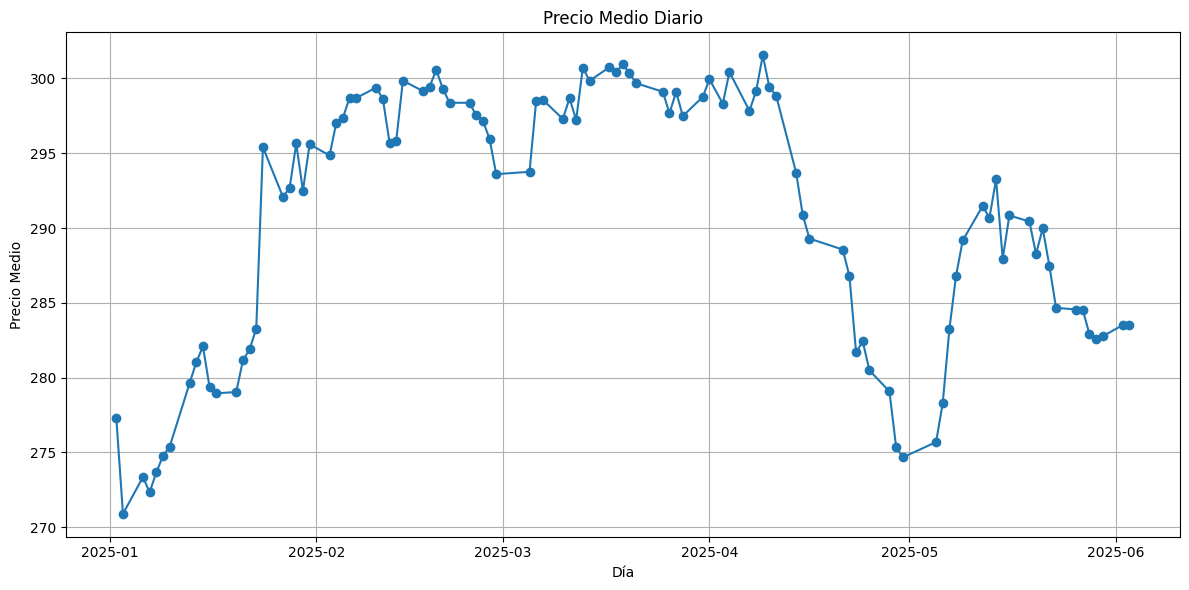

In [17]:
## Genero un gráfico de la columna preciomedio
plt.figure(figsize=(12, 6))
plt.plot(result.index, result["preciomedio"], marker='o')
plt.xlabel("Día")
plt.ylabel("Precio Medio")
plt.title("Precio Medio Diario")
plt.grid(True)
plt.tight_layout()
plt.show()

Busco los datos del precio soja en $ disponible  

In [18]:
end = datetime.date.today()
start = datetime.date(year=2025, month=1, day=1)

instrument = "SOJ.ROS.P/DISPO"  ## Instrumento a consultar


ht = pyRofex.get_trade_history(ticker=instrument, start_date=start, end_date=end)
tr=ht["trades"]
ptrdi=pd.DataFrame(tr,columns=["symbol","size","price","datetime"])
ptrdi["dia"]= pd.to_datetime( ptrdi["datetime"].str[:10], format='%Y-%m-%d') ## Creo columan dia
ptrdi=ptrdi.drop(['datetime'], axis=1)  ##Saco columna datetiem
ptrdi=ptrdi.set_index("dia")
ptrdi["monto"] = ptrdi["size"] * ptrdi["price"] 
ptrdi=ptrdi.groupby(by=["dia"]).agg({'size':'sum', 'price': 'max', 'monto': 'sum'}) ## Agrupo por dia
ptrdi["preciomedio"] = ptrdi["monto"] / ptrdi["size"]
print(ptrdi)

             size     price       monto    preciomedio
dia                                                   
2025-01-03    5.0  285000.0   1425000.0  285000.000000
2025-01-10    4.0  290000.0   1160000.0  290000.000000
2025-01-13   14.0  298000.0   4172000.0  298000.000000
2025-01-16   25.0  290000.0   7209000.0  288360.000000
2025-01-17    7.0  290000.0   2030000.0  290000.000000
2025-01-21    1.0  293000.0    293000.0  293000.000000
2025-01-22    3.0  295000.0    885000.0  295000.000000
2025-01-23    6.0  297000.0   1780000.0  296666.666667
2025-01-28   17.0  312000.0   5290000.0  311176.470588
2025-01-30    3.0  314500.0    943500.0  314500.000000
2025-02-04   10.0  320000.0   3200000.0  320000.000000
2025-02-05   23.0  322000.0   7406000.0  322000.000000
2025-02-06    7.0  322000.0   2250000.0  321428.571429
2025-02-07   24.0  323000.0   7728000.0  322000.000000
2025-02-11    2.0  323000.0    646000.0  323000.000000
2025-02-18   12.0  332000.0   3984000.0  332000.000000
2025-02-20

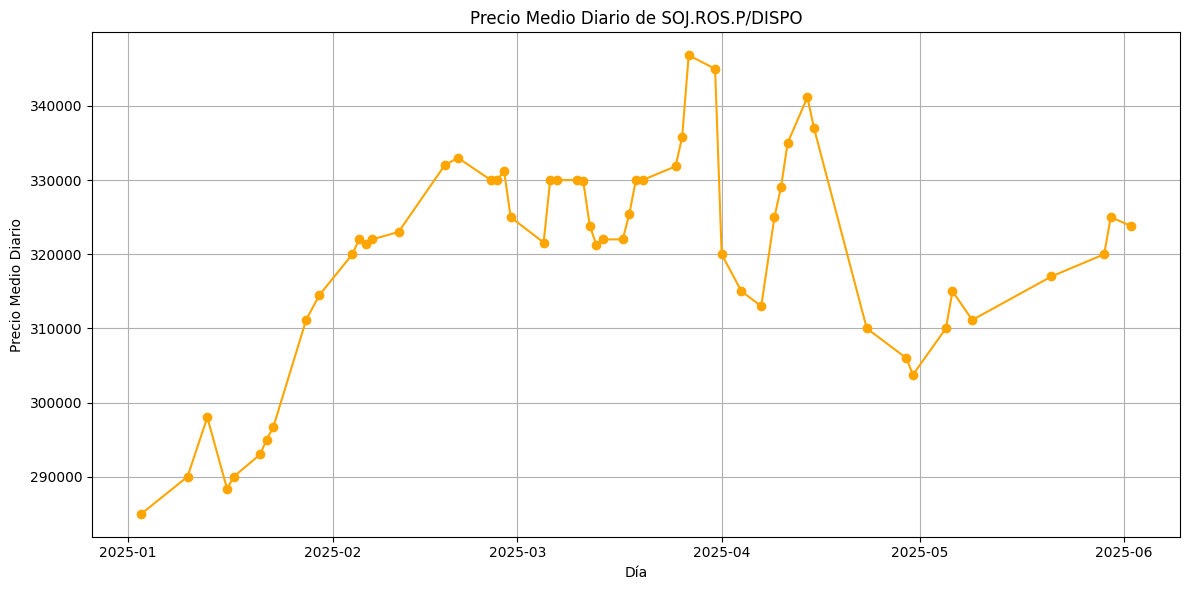

In [19]:
# Graficar el resultado
plt.figure(figsize=(12, 6))     
plt.plot(ptrdi.index, ptrdi["preciomedio"], marker='o', color='orange')
plt.xlabel("Día")
plt.ylabel("Precio Medio Diario")
plt.title("Precio Medio Diario de SOJ.ROS.P/DISPO")
plt.grid(True)
plt.tight_layout()                 
plt.savefig("soj_ros_p_dispo_precio_medio_diario.png", dpi=300)

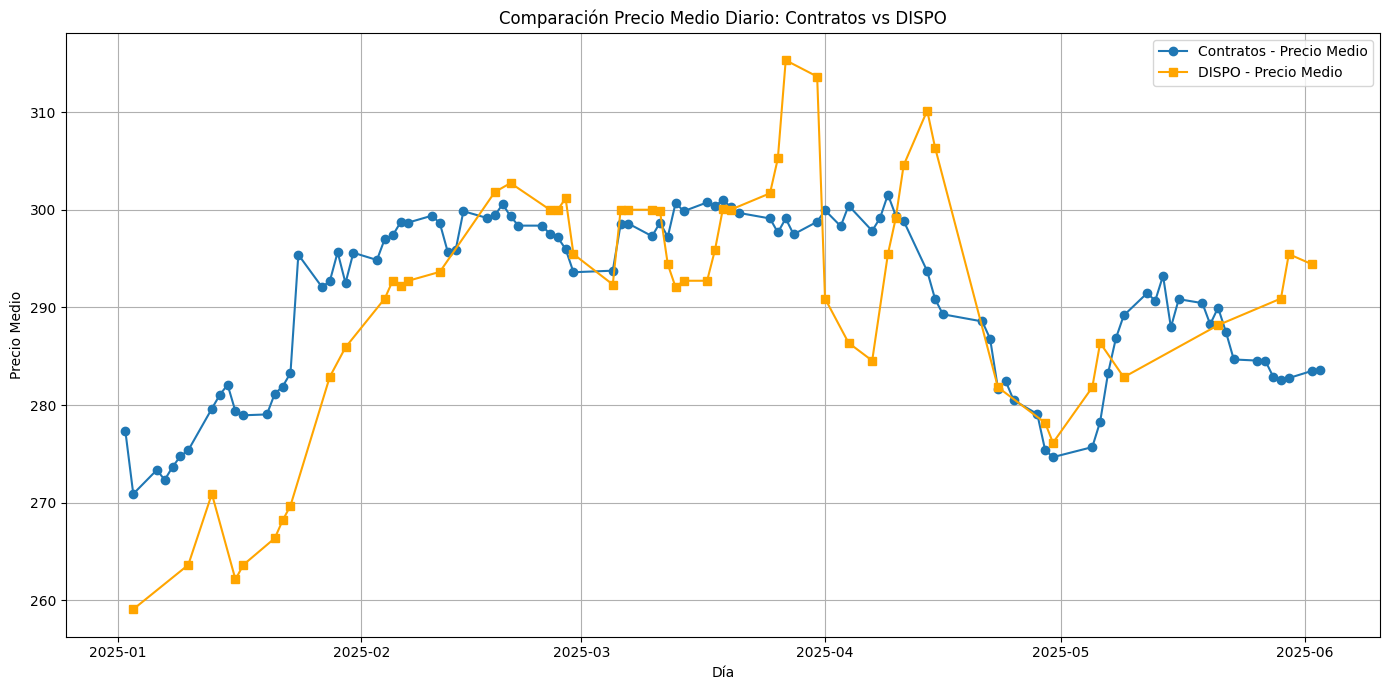

In [20]:
## Genero un gráfico de la columna preciomedio suponiendo precio del dolar a 1100 pesos
plt.figure(figsize=(14, 7))
plt.plot(result.index, result["preciomedio"], label="Contratos - Precio Medio", marker='o')
plt.plot(ptrdi.index, ptrdi["preciomedio"]/1100, label="DISPO - Precio Medio", marker='s', color='orange')
plt.xlabel("Día")
plt.ylabel("Precio Medio")
plt.title("Comparación Precio Medio Diario: Contratos vs DISPO")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [45]:
## Obteniendo el valor del Dólar (ARS/USD) en los últimos 365 días usando yfinance
# Asegúrate de tener instalado el paquete yfinance: pip install yfinance    

import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

# Definir el ticker para el par ARS/USD
# ARS=X significa el valor de 1 Peso Argentino en Dólares Estadounidenses
# USDARS=X significaría el valor de 1 Dólar Estadounidense en Pesos Argentinos (más común)

ticker_ars_usd = "ARS=X" # Si quieres saber cuánto vale 1 ARS en USD
# ticker_ars_usd = "USDARS=X"

# Definir el rango de fechas para los últimos 365 días
end_date = datetime.now()
start_date = end_date - timedelta(days=365)

# Convertir las fechas a formato 'YYYY-MM-DD'
start_date_str = start_date.strftime('%Y-%m-%d')
end_date_str = end_date.strftime('%Y-%m-%d')

print(f"Consultando el valor del Dólar (ARS/USD) desde {start_date_str} hasta {end_date_str}")

try:
    # Descargar los datos para ARS=X
    valorpeso= yf.download(ticker_ars_usd, start=start_date_str, end=end_date_str)


    print(f"\n--- Datos del par {ticker_ars_usd} (1 ARS en USD) ---")
    if not valorpeso.empty:
        print(valorpeso.head()) # Muestra las primeras filas
        print(valorpeso.tail()) # Muestra las últimas filas
        print(f"\nValor promedio de 1 ARS en USD en los últimos 365 días: {valorpeso[('Close', 'ARS=X')].mean():.8f} USD")
        print(f"Valor mínimo de 1 ARS en USD en los últimos 365 días: {valorpeso[('Close', 'ARS=X')].min():.8f} USD")
        print(f"Valor máximo de 1 ARS en USD en los últimos 365 días: {valorpeso[('Close', 'ARS=X')].max():.8f} USD")
    else:
        print(f"No se encontraron datos para {ticker_ars_usd} en el período especificado.")

except Exception as e:
    print(f"Ocurrió un error al descargar los datos: {e}")

[*********************100%***********************]  1 of 1 completed

Consultando el valor del Dólar (ARS/USD) desde 2024-06-03 hasta 2025-06-03

--- Datos del par ARS=X (1 ARS en USD) ---
Price            Close        High         Low        Open Volume
Ticker           ARS=X       ARS=X       ARS=X       ARS=X  ARS=X
Date                                                             
2024-06-03  894.222778  897.073486  893.488647  894.222778      0
2024-06-04  896.545166  897.258240  895.186523  896.545166      0
2024-06-05  897.011475  898.103516  896.780701  897.011475      0
2024-06-06  898.504150  898.820190  897.493408  898.504150      0
2024-06-07  898.503296  899.497070  898.279602  898.503296      0
Price             Close         High          Low         Open Volume
Ticker            ARS=X        ARS=X        ARS=X        ARS=X  ARS=X
Date                                                                 
2025-05-28  1156.496094  1165.501221  1152.911011  1156.496094      0
2025-05-29  1160.255371  1180.000244  1152.398560  1160.255371      0
202

In [46]:
## Framwork de los valores del Dólar le creo la columna 'Dolar' y renombro el índice a 'Dia'
valorpeso.index.name = "Dia"  # Renombrar el índice a "Fecha"
valorpeso = valorpeso.rename(columns={'Close': 'Dolar'})
print(valorpeso.head())  # Mostrar las primeras filas del DataFrame limpio

Price            Dolar        High         Low        Open Volume
Ticker           ARS=X       ARS=X       ARS=X       ARS=X  ARS=X
Dia                                                              
2024-06-03  894.222778  897.073486  893.488647  894.222778      0
2024-06-04  896.545166  897.258240  895.186523  896.545166      0
2024-06-05  897.011475  898.103516  896.780701  897.011475      0
2024-06-06  898.504150  898.820190  897.493408  898.504150      0
2024-06-07  898.503296  899.497070  898.279602  898.503296      0


In [47]:
valorpeso = valorpeso.rename(columns={'Close': 'Dolar'})

In [48]:
print(valorpeso.head())  # Mostrar las primeras filas del DataFrame limpio

Price            Dolar        High         Low        Open Volume
Ticker           ARS=X       ARS=X       ARS=X       ARS=X  ARS=X
Dia                                                              
2024-06-03  894.222778  897.073486  893.488647  894.222778      0
2024-06-04  896.545166  897.258240  895.186523  896.545166      0
2024-06-05  897.011475  898.103516  896.780701  897.011475      0
2024-06-06  898.504150  898.820190  897.493408  898.504150      0
2024-06-07  898.503296  899.497070  898.279602  898.503296      0


In [38]:
print(ptrdi)    

             size     price       monto    preciomedio
dia                                                   
2025-01-03    5.0  285000.0   1425000.0  285000.000000
2025-01-10    4.0  290000.0   1160000.0  290000.000000
2025-01-13   14.0  298000.0   4172000.0  298000.000000
2025-01-16   25.0  290000.0   7209000.0  288360.000000
2025-01-17    7.0  290000.0   2030000.0  290000.000000
2025-01-21    1.0  293000.0    293000.0  293000.000000
2025-01-22    3.0  295000.0    885000.0  295000.000000
2025-01-23    6.0  297000.0   1780000.0  296666.666667
2025-01-28   17.0  312000.0   5290000.0  311176.470588
2025-01-30    3.0  314500.0    943500.0  314500.000000
2025-02-04   10.0  320000.0   3200000.0  320000.000000
2025-02-05   23.0  322000.0   7406000.0  322000.000000
2025-02-06    7.0  322000.0   2250000.0  321428.571429
2025-02-07   24.0  323000.0   7728000.0  322000.000000
2025-02-11    2.0  323000.0    646000.0  323000.000000
2025-02-18   12.0  332000.0   3984000.0  332000.000000
2025-02-20

In [49]:
## RElacion las Tablas ptrdi y valorpeso por la columna 'Dia'
ptrdi_usd = ptrdi.join(valorpeso['Dolar'], how='left' )  # Unir ptrdi con valorpeso por el índice (fecha)

# Calcular el preciomedio en dólares
ptrdi_usd['preciomediodolar'] = ptrdi_usd['preciomedio'] / ptrdi_usd['Dolar']

print(ptrdi_usd[['preciomedio', 'Dolar', 'preciomediodolar']])

KeyError: 'Dolar'

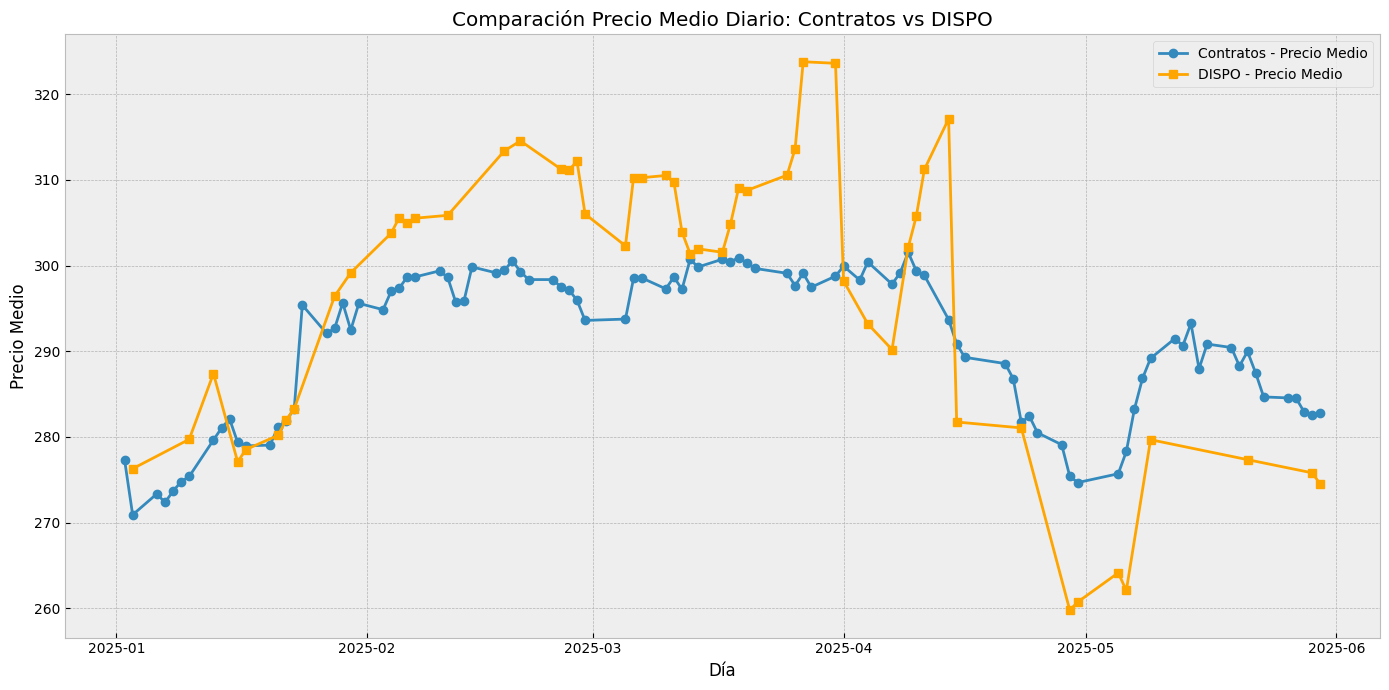

In [ ]:
## Grafico comparando el precio medio de los contratos y el precio medio del DISPO en dólares
plt.figure(figsize=(14, 7))
plt.plot(result.index, result["preciomedio"], label="Contratos - Precio Medio", marker='o')
plt.plot(ptrdi_usd.index, ptrdi_usd["preciomediodolar"], label="DISPO - Precio Medio", marker='s', color='orange')
plt.xlabel("Día")
plt.ylabel("Precio Medio")
plt.title("Comparación Precio Medio Diario: Contratos vs DISPO")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()